In [138]:
import base64
import os
from google import genai
from IPython.display import Image, display
from dataclasses import dataclass
from urllib.error import HTTPError, URLError
from urllib.request import Request, urlopen


In [139]:
api_key = os.environ.get("GEMINI_API_KEY") or getpass("Gemini API key: ")

In [140]:
client = genai.Client()

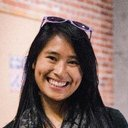

In [141]:
user_image_url = "https://randomuser.me/api/portraits/women/8.jpg"
# user_image_url = "https://www.touchableai.shop/logo.svg"
# user_image_url = "https://media-cdn.june.date/touchable/production/assets/favicons/64x64.png"

@dataclass(frozen=True)
class DownloadedImage:
    data: bytes
    mime_type: str


def download_image(url: str, timeout: float = 30.0) -> DownloadedImage:
    if not url.lower().startswith(("http://", "https://")):
        raise ValueError(f"Image URL must use http or https: {url!r}")

    request = Request(url, headers={"User-Agent": "image-generator-evaluator-notebook/1.0"})
    try:
        with urlopen(request, timeout=timeout) as response:
            mime_type = response.headers.get_content_type().lower()
            if not mime_type.startswith("image/"):
                raise ValueError(
                    f"URL did not return an image (Content-Type: {mime_type!r}): {url}"
                )
            data = response.read()
    except HTTPError as exc:
        raise RuntimeError(f"Image request failed with HTTP {exc.code}: {url}") from exc
    except URLError as exc:
        raise RuntimeError(f"Could not download image from {url}: {exc.reason}") from exc

    if not data:
        raise ValueError(f"Image response was empty: {url}")

    return DownloadedImage(data=data, mime_type=mime_type)


reference_image = download_image(user_image_url)
display(Image(data=reference_image.data, width=300))

In [142]:
reference_image.mime_type

'image/jpeg'

In [ ]:

# MODEL = "gemini-2.5-flash-image"
MODEL = "gemini-3.1-flash-image"

STYLE = ["art noir", "warli", "art deco", "pop art", "kawaii", "pixel art", "madhubani"]

PROMPT_TEMPLATE = "A {style_name} style sticker of the character based on the uploaded image. The design features bold, clean outlines, simple cel-shading, and a vibrant color palette. The background must be white."

RESPONSE_FORMAT = {
  "type": "image",
  "mime_type": "image/jpeg",
}


In [144]:
def generate_sticker(prompt, reference_image=reference_image):
    try:
        interaction = client.interactions.create(
            model=MODEL,
            input=[
                {"type": "text", "text": prompt},
                {
                    "type": "image",
                    "data": base64.b64encode(reference_image.data).decode("ascii"),
                    "mime_type": reference_image.mime_type,
                }
            ],
            response_format=RESPONSE_FORMAT,
        )
        print(f"Interaction ID: {interaction.id}")
        generated_image = interaction.output_image.data
        display(Image(data=base64.b64decode(generated_image), width=600))

        return interaction
    except Exception as e:
        print(f"Error generating image: {e}")

Generating sticker in art noir style...
Interaction ID: v1_ChdiLU84YXFhV01MLTFnOFVQaXVLOHlRbxIXYi1POGFxYVdNTC0xZzhVUGl1Szh5UW8


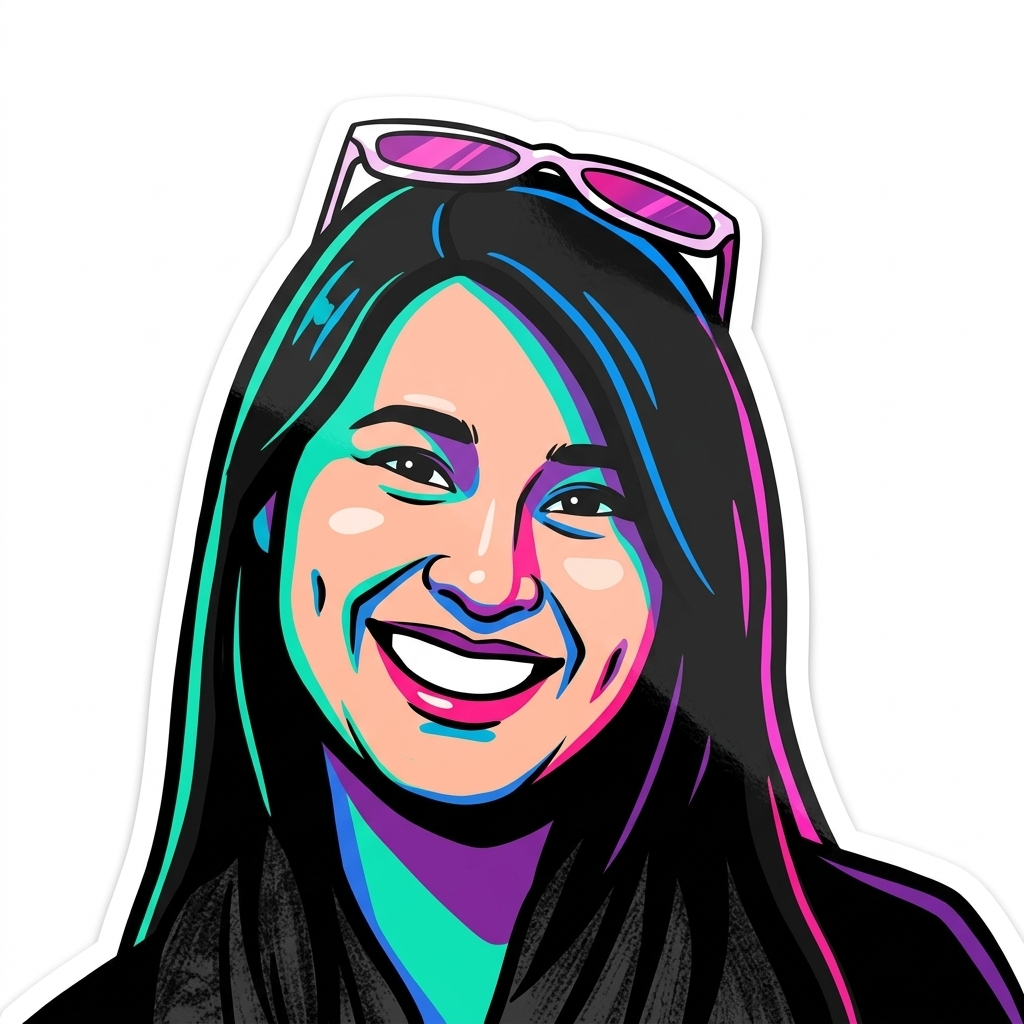

Generating sticker in warli style...
Interaction ID: v1_ChdqZU84YXNhNE1wYXpnOFVQaTlMNC1BYxIXamVPOGFzYTRNcGF6ZzhVUGk5TDQtQWM


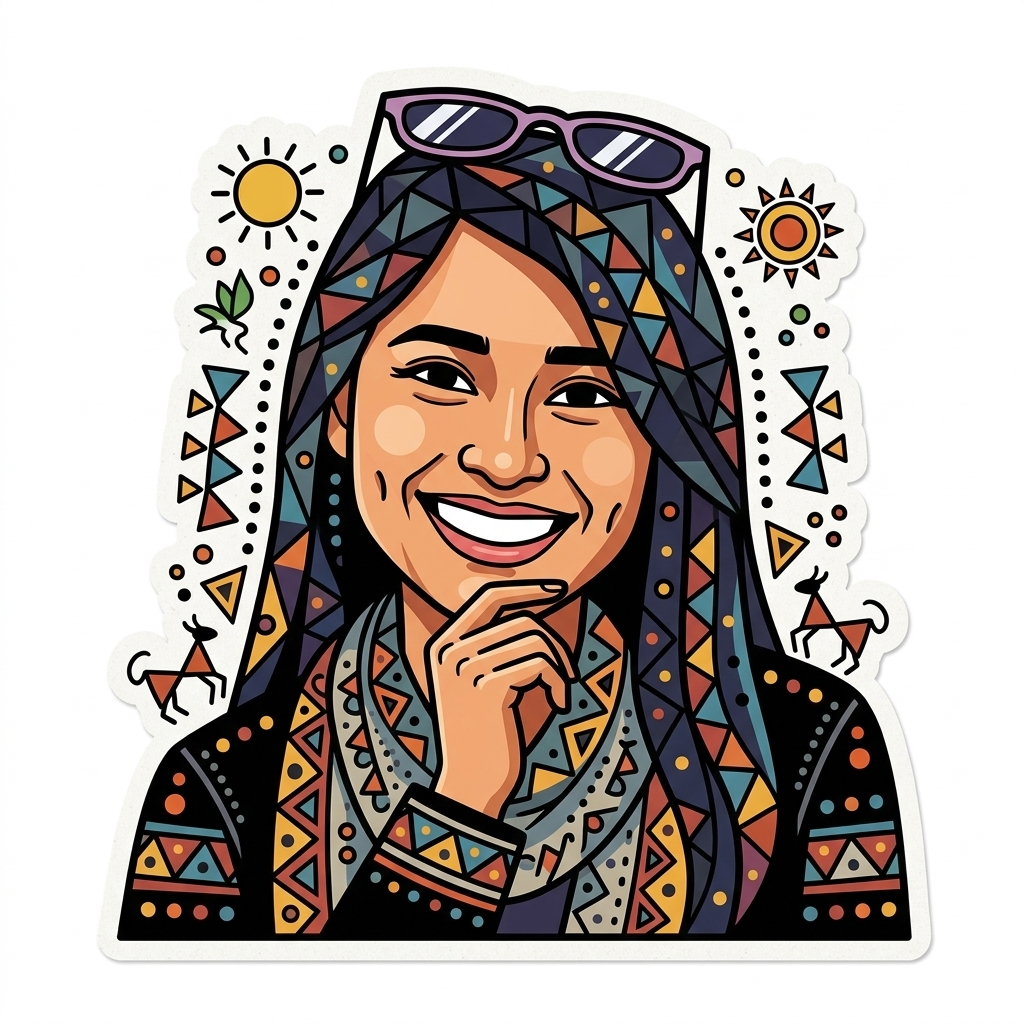

Generating sticker in art deco style...
Interaction ID: v1_ChdrZU84YXUzMU52YXpnOFVQaHZIMTJBVRIXa2VPOGF1MzFOdmF6ZzhVUGh2SDEyQVU


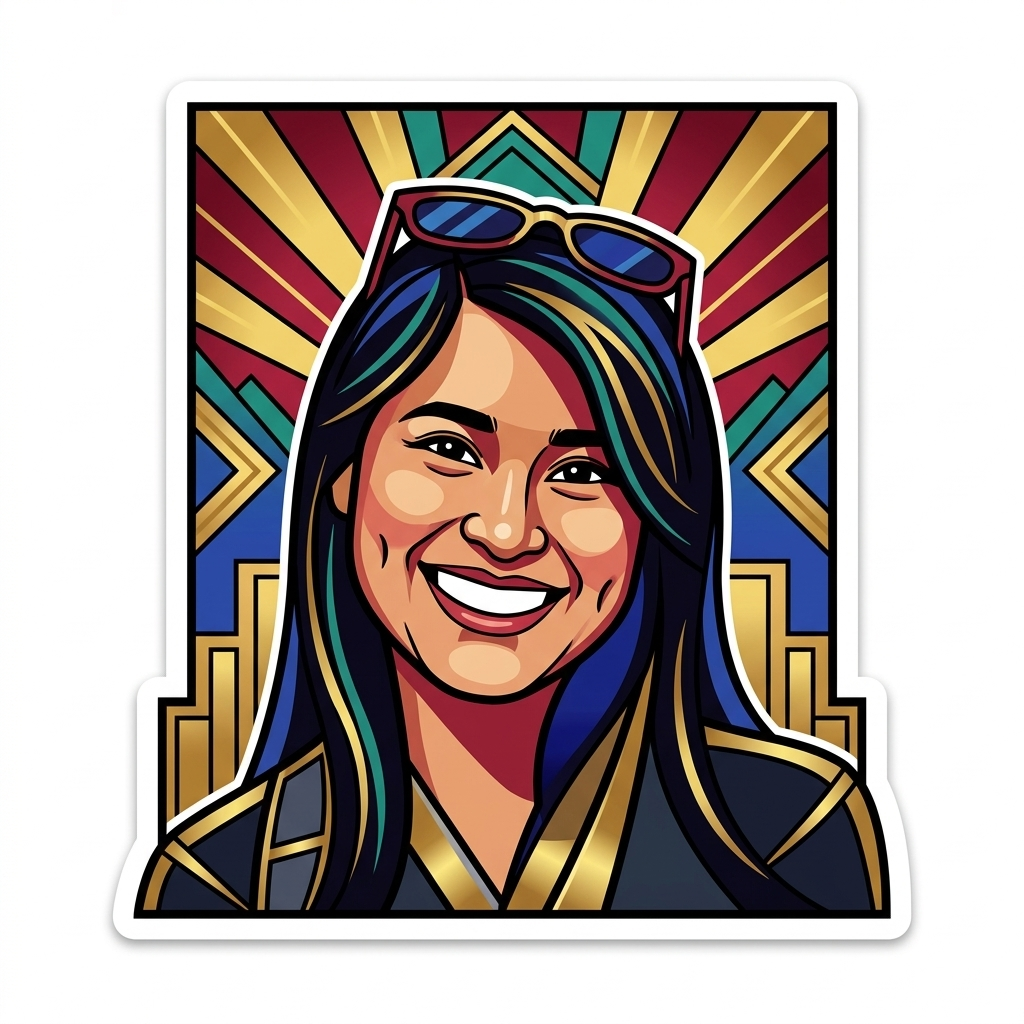

Generating sticker in pop art style...
Interaction ID: v1_ChdxT084YXRYREp0bkRnOFVQcy1HbjJBURIXcU9POGF0WERKdG5EZzhVUHMtR24yQVE


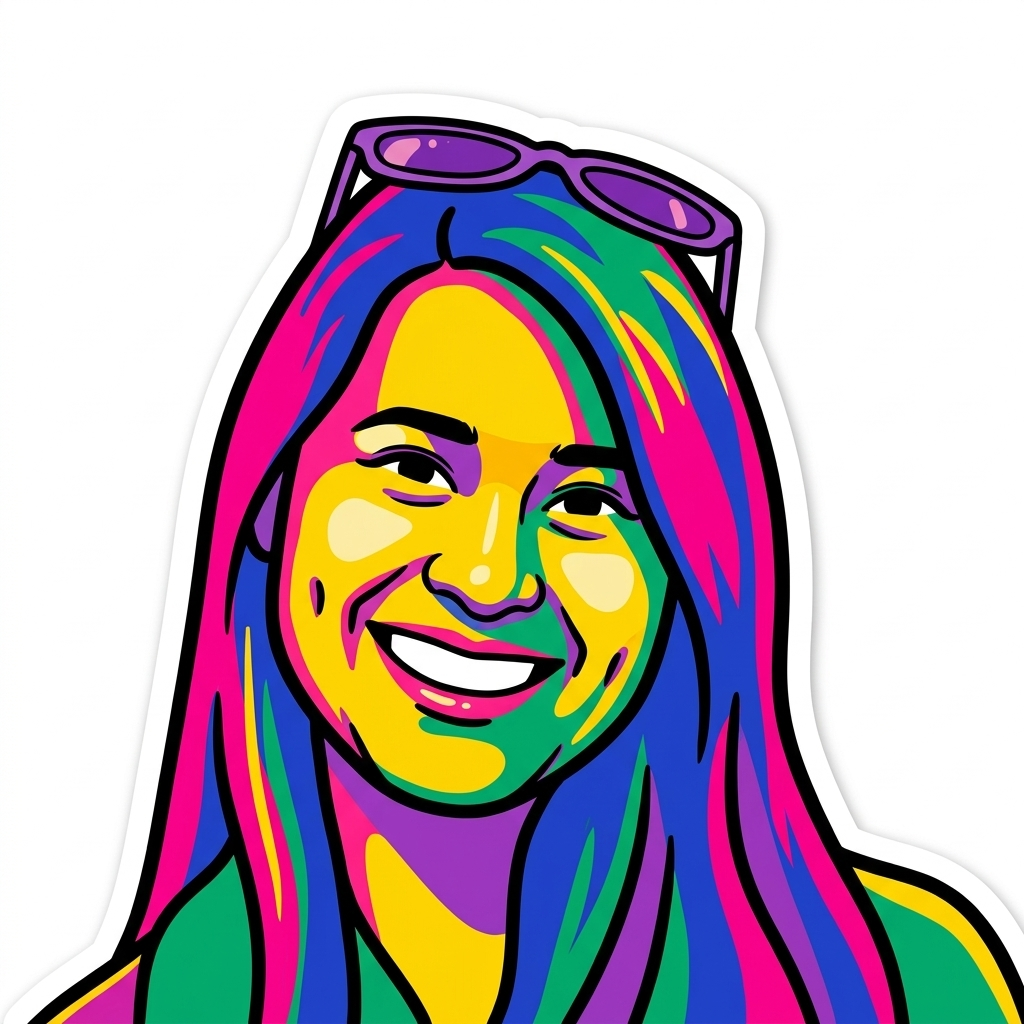

Generating sticker in kawaii style...
Interaction ID: v1_Chd0dU84YW9fYU11T3NnOFVQcUozbzBRVRIXdHVPOGFvX2FNdU9zZzhVUHFKM28wUVU


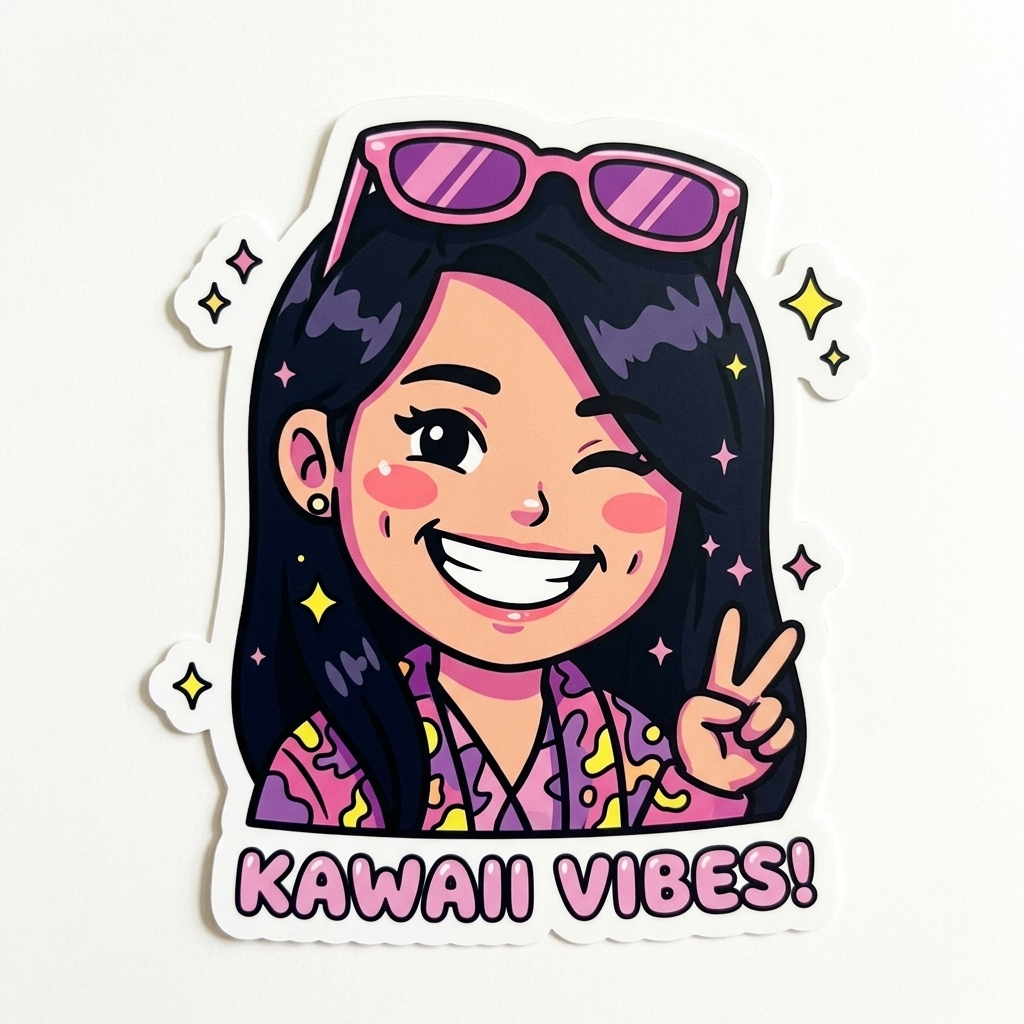

Generating sticker in pixel art style...
Interaction ID: v1_Chd4T084YW95Y0JaLTBnOFVQcFpXRmtRZxIXeE9POGFveWNCWi0wZzhVUHBaV0ZrUWc


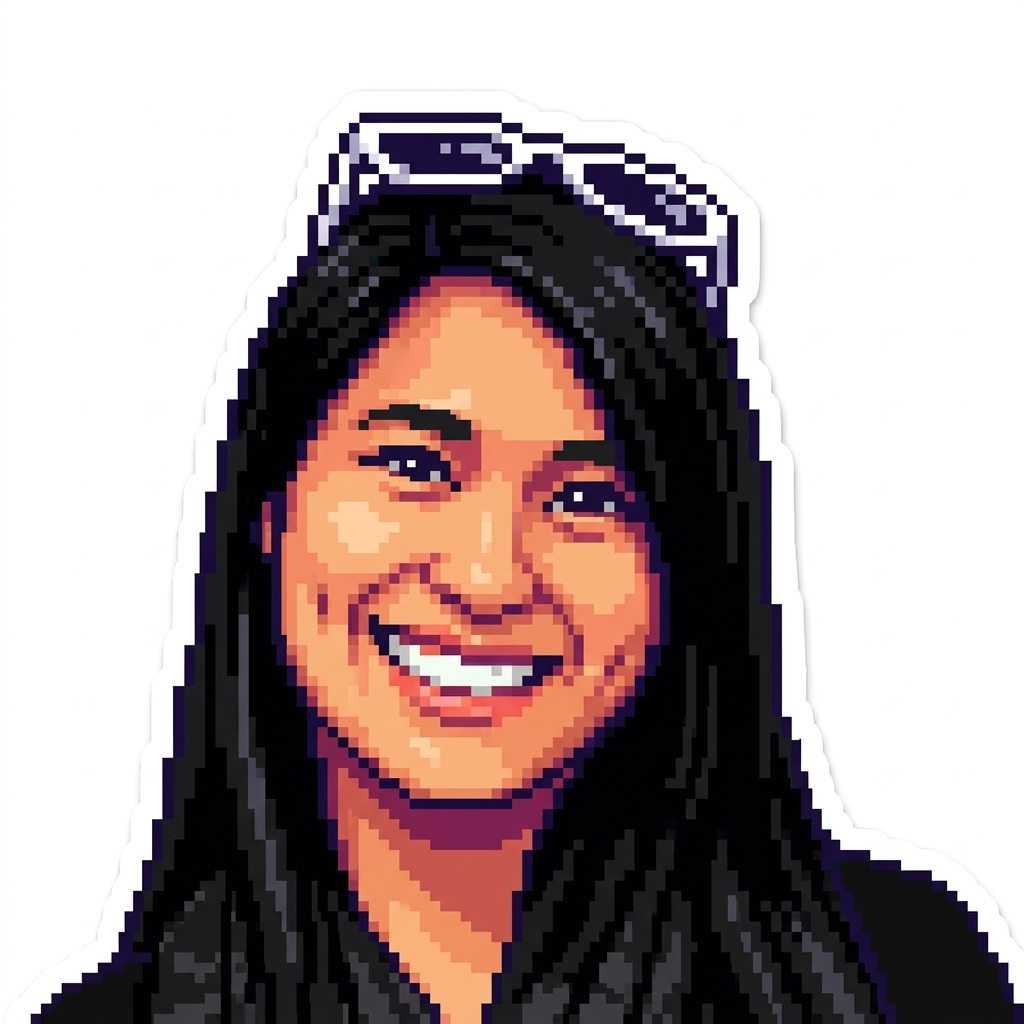

Generating sticker in madhubani style...
Interaction ID: v1_Chd5T084YXVHMUU3Mm9nOFVQXzhTOHNBYxIXeU9POGF1RzFFNzJvZzhVUF84UzhzQWM


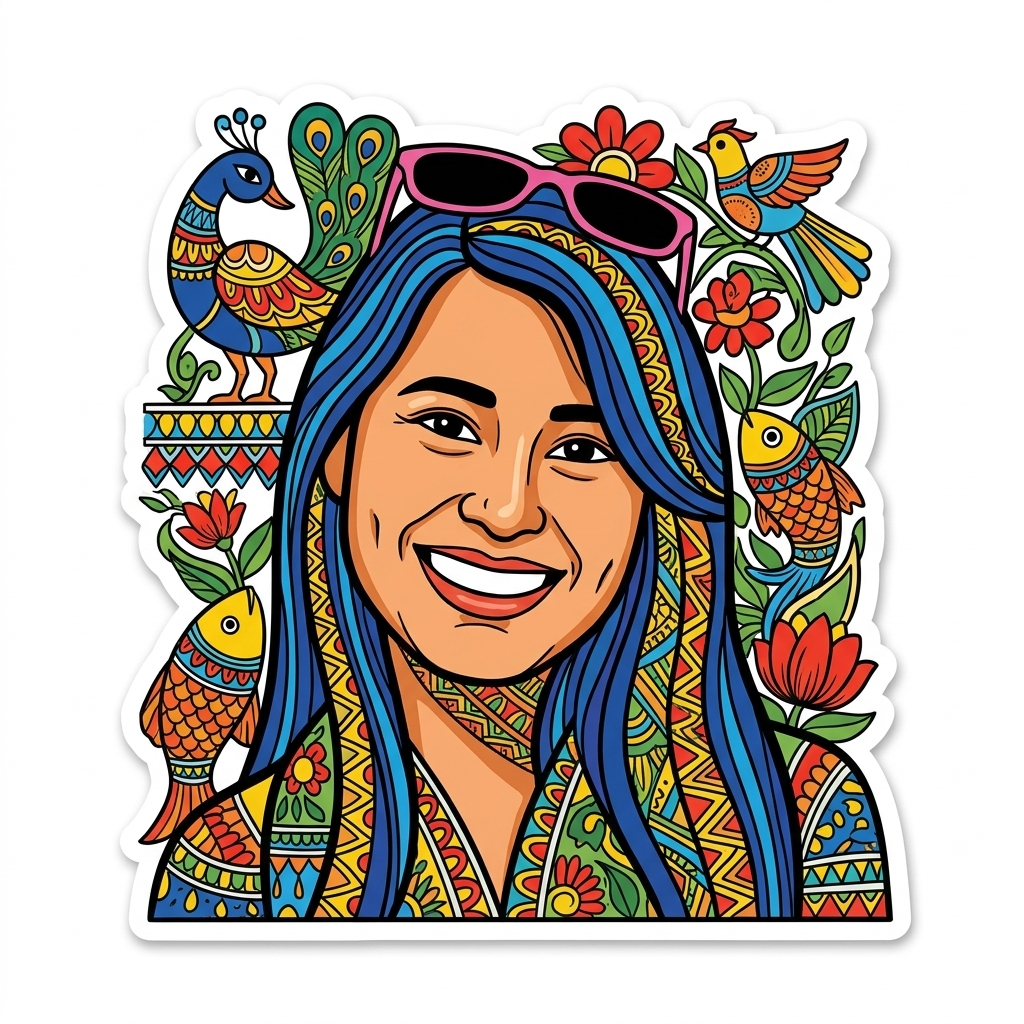

In [145]:
# Turn 1

for style in STYLE:
    prompt = PROMPT_TEMPLATE.format(style_name=style)
    print(f"Generating sticker in {style} style...")
    interaction = generate_sticker(prompt=prompt, reference_image=reference_image)